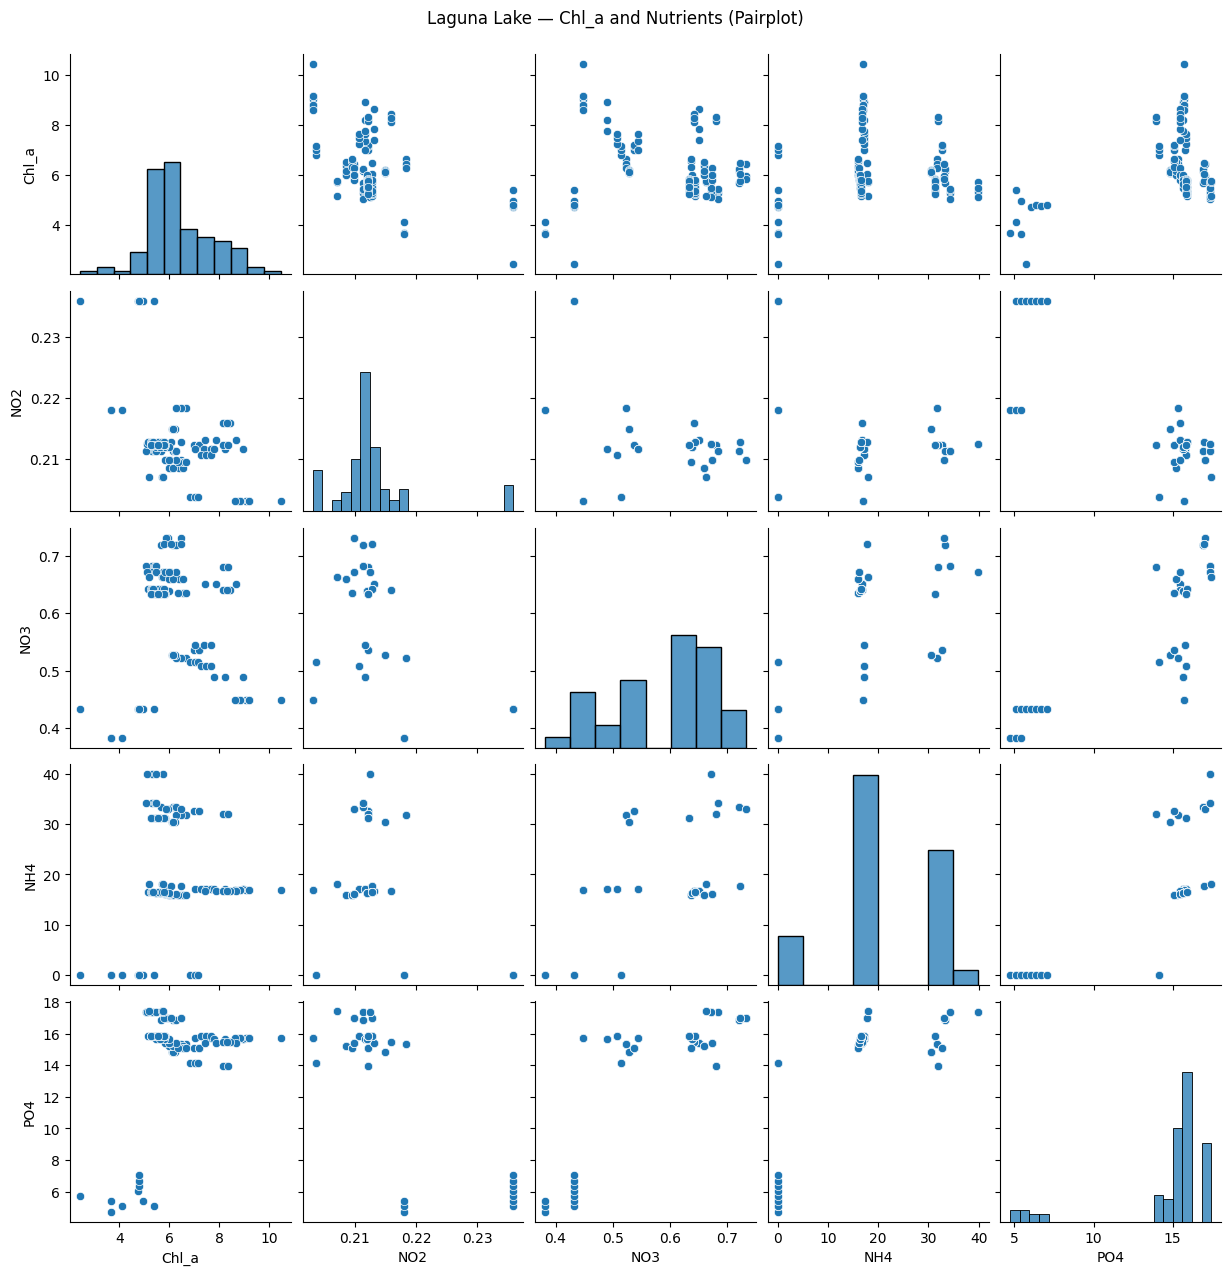

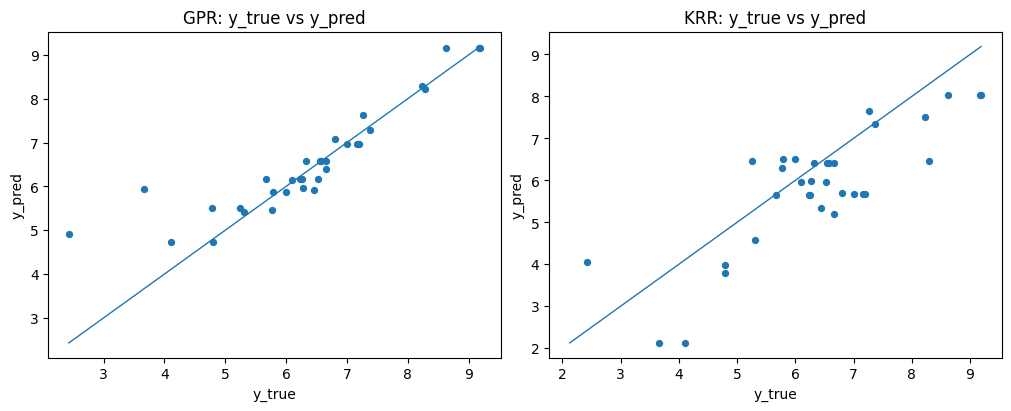


==================== FINAL ANSWERS (MEX 2 — Problem 2) ====================
(b) Test RMSE — GPR : 0.6508
(c) Test RMSE — KRR : 0.9966
Comparison (lower RMSE is better): GPR better or tie



In [19]:
# === MEX 2 — Problem 2 (one-cell, drop-in) ====================================
# Predicting Chlorophyll-a (Chl_a) from NO2, NO3, NH4, PO4

import warnings; warnings.filterwarnings("ignore")
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path
from sklearn.model_selection import train_test_split
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error

# Models
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, WhiteKernel, ConstantKernel as C
from sklearn.kernel_ridge import KernelRidge

# -------------------------
# Load dataset (local then fallback to URL)
# -------------------------
def load_chlor():
    local = Path("chlor.csv")
    if local.exists():
        df = pd.read_csv(local)
    else:
        df = pd.read_csv("https://raw.githubusercontent.com/kspilario/predict_chlorophyll/main/chlor.csv")
    # Keep: Chl_a (output), NO2, NO3, NH4, PO4 (inputs)
    # In the provided CSV these are columns: 0,2,3,4,5
    df = df.iloc[:, [0, 2, 3, 4, 5]].copy()
    df.columns = ["Chl_a", "NO2", "NO3", "NH4", "PO4"]
    return df

df = load_chlor().dropna().reset_index(drop=True)

# -------------------------
# (a) Pairplot (EDA)
# -------------------------
sns.pairplot(df, diag_kind="hist")
plt.suptitle("Laguna Lake — Chl_a and Nutrients (Pairplot)", y=1.02)
plt.show()

# -------------------------
# Train/Test split (70/30)
# -------------------------
X = df[["NO2","NO3","NH4","PO4"]].values          # inputs
y = df["Chl_a"].values                             # target (1-D)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.30, random_state=42
)

# -------------------------
# (b) StandardScaler + GaussianProcessRegressor
# -------------------------
kernel = (
    C(1.0, (1e-3, 1e3)) *
    RBF(length_scale=np.ones(X.shape[1]), length_scale_bounds=(1e-2, 1e3))
    + WhiteKernel(noise_level=1.0, noise_level_bounds=(1e-6, 1e1))
)

GPR = make_pipeline(
    StandardScaler(),
    GaussianProcessRegressor(
        kernel=kernel,
        alpha=0.0,                 # noise handled by WhiteKernel
        normalize_y=True,
        random_state=42,
        n_restarts_optimizer=2
    )
)

GPR.fit(X_train, y_train)
y_pred_gpr = GPR.predict(X_test)
rmse_gpr = np.sqrt(mean_squared_error(y_test, y_pred_gpr))

# -------------------------
# (c) StandardScaler + Kernel Ridge Regression (RBF)
# -------------------------
KRR = make_pipeline(
    StandardScaler(),
    KernelRidge(kernel="rbf", alpha=1.0, gamma=None)
)

KRR.fit(X_train, y_train)
y_pred_krr = KRR.predict(X_test)
rmse_krr = np.sqrt(mean_squared_error(y_test, y_pred_krr))

# -------------------------
# Parity plots (optional but nice)
# -------------------------
fig, ax = plt.subplots(1, 2, figsize=(10, 4), constrained_layout=True)

# GPR parity
ax[0].scatter(y_test, y_pred_gpr, s=18)
lims0 = [min(y_test.min(), y_pred_gpr.min()), max(y_test.max(), y_pred_gpr.max())]
ax[0].plot(lims0, lims0, lw=1)
ax[0].set_title("GPR: y_true vs y_pred")
ax[0].set_xlabel("y_true"); ax[0].set_ylabel("y_pred")

# KRR parity
ax[1].scatter(y_test, y_pred_krr, s=18)
lims1 = [min(y_test.min(), y_pred_krr.min()), max(y_test.max(), y_pred_krr.max())]
ax[1].plot(lims1, lims1, lw=1)
ax[1].set_title("KRR: y_true vs y_pred")
ax[1].set_xlabel("y_true"); ax[1].set_ylabel("y_pred")

plt.show()

# -------------------------
# FINAL ANSWERS (highlight these in your notebook)
# -------------------------
print("\n==================== FINAL ANSWERS (MEX 2 — Problem 2) ====================")
print(f"(b) Test RMSE — GPR : {rmse_gpr:.4f}")
print(f"(c) Test RMSE — KRR : {rmse_krr:.4f}")
print("Comparison (lower RMSE is better):",
      "KRR better" if rmse_krr < rmse_gpr else "GPR better or tie")
print("=========================================================================\n")
